In [1]:
# Cellule 1 : Importations
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy.stats import linregress
import time
import os
os.path.abspath("dynamical_exponent.ipynb")

'c:\\Users\\conta\\Documents\\ERASMUS\\transition phase\\Projet TF\\PhaseTransitionsProject\\dynamical_exponent.ipynb'

In [2]:
# Cellule 2 : Fonctions d'autocorrélation et de calcul de tau
def autocorrelation_fft(x, maxlag=None):
    x = np.asarray(x, dtype=float)
    n = x.size
    if maxlag is None:
        maxlag = n - 1
    mean = x.mean()
    x = x - mean
    m = 1 << (int(np.log2(2*n - 1)) + 1)
    fx = np.fft.rfft(x, n=m)
    acfull = np.fft.irfft(fx * np.conjugate(fx), n=m)[:n]
    acfull = acfull / n
    var = x.var()
    if var == 0:
        return np.ones(maxlag+1)
    ac = acfull[:maxlag+1] / var
    return ac

def integrated_tau_from_ac(ac, c_factor=5, max_iter=200):
    if len(ac) < 2:
        return 0.5
    tau = 0.5
    for _ in range(max_iter):
        W = min(len(ac)-1, max(1, int(c_factor * tau)))
        new_tau = 0.5 + np.sum(ac[1:W+1])
        if not np.isfinite(new_tau):
            return np.inf
        if abs(new_tau - tau) < 1e-6:
            return new_tau
        tau = new_tau
    return tau

def iterative_burn_and_tau(observable, c_factor=3, max_iter=10, min_fraction=0.001, verbose=False):
    n = len(observable)
    burn = 0
    prev_burn = -1
    tau = None

    for it in range(max_iter):
        data = observable[burn:]
        if len(data) < max(100, int(min_fraction * n)):
            if verbose:
                print(f"  [iter {it}] série restante trop courte ({len(data)}), stop.")
            break

        maxlag = min(len(data)-1, max(100, len(data)//10, 1000))
        ac = autocorrelation_fft(data, maxlag=maxlag)
        tau = integrated_tau_from_ac(ac, c_factor=c_factor)

        if not np.isfinite(tau) or tau <= 0:
            if verbose:
                print(f"  [iter {it}] τ invalid (tau={tau}), abort iteration.")
            tau = np.inf
            break

        new_burn = int(c_factor * tau)
        if verbose:
            print(f"  [iter {it}] len(data)={len(data)}, tau={tau:.3f}, new_burn={new_burn}")

        if new_burn >= len(observable):
            if verbose:
                print(f"  new_burn ({new_burn}) >= série totale ({len(observable)}): abort.")
            burn = len(observable)
            tau = np.inf
            break

        if new_burn == prev_burn:
            burn = new_burn
            break

        prev_burn = new_burn
        burn = new_burn

    data = observable[burn:]
    if len(data) < max(100, int(min_fraction * n)):
        if verbose:
            print(f"  Final: série restante trop courte ({len(data)}). τ non calculé.")
        return burn, np.inf, np.array([np.nan])

    maxlag = min(len(data)-1, 10000, max(100, len(data)//10))
    ac = autocorrelation_fft(data, maxlag=maxlag)
    tau = integrated_tau_from_ac(ac, c_factor=c_factor)

    return burn, tau, ac


In [9]:
# Cellule 3 : Configuration des données
base_dir = "data/Metropolis_Temp_Scan_1_Million_Sweeps"
beta_c = 0.4407
h = 0.0

L_list = []
for folder in os.listdir(base_dir):
    m = re.match(r"L_(\d+)", folder)
    if m:
        L_list.append(int(m.group(1)))
L_list = sorted(L_list)
print("Tailles détectées :", L_list)


Tailles détectées : [2, 4, 8, 16, 32, 64, 128]


In [17]:
# Cellule 4 : Boucle principale de traitement (version corrigée)
tau_vs_L = []
skipped = []

start_all = time.time()
for L in L_list:
    print(f"\n===== Traitement L = {L} =====")
    file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    if not os.path.exists(file_path):
        print(f"⚠️ Fichier absent : {file_path}")
        skipped.append((L, "missing file"))
        continue

    data = np.load(file_path)
    mags = data["magnetizations"]
    N = len(mags)
    print(f"Longueur série = {N}")

    # --------------------------
    # Burn manuel pour petites tailles L
    # --------------------------
    if L <= 4:  # seuil ajustable
        burn_manual = 50000  # enlever les premiers 50k sweeps
        if N > burn_manual:
            mags = mags[burn_manual:]
            print(f"  Burn manuel appliqué : {burn_manual} sweeps retirés")
        else:
            print("  ⚠️ Série trop courte pour burn manuel, on prend tout")

    # --------------------------
    # Limite maxlag pour petites tailles
    # --------------------------
    maxlag_limit = None
    if L <= 4:
        maxlag_limit = min(len(mags)-1, 5000)

    t0 = time.time()
    if maxlag_limit is not None:
        # Passer maxlag limité à la fonction
        def iterative_burn_and_tau_with_maxlag(obs, **kwargs):
            n = len(obs)
            burn = 0
            prev_burn = -1
            tau = None

            for it in range(kwargs.get('max_iter', 10)):
                data = obs[burn:]
                if len(data) < max(100, int(kwargs.get('min_fraction',0.001) * n)):
                    break
                ac = autocorrelation_fft(data, maxlag=maxlag_limit)
                tau = integrated_tau_from_ac(ac, c_factor=kwargs.get('c_factor',3))
                if not np.isfinite(tau) or tau <= 0:
                    tau = np.inf
                    break
                new_burn = int(kwargs.get('c_factor',3) * tau)
                if new_burn >= len(obs):
                    burn = len(obs)
                    tau = np.inf
                    break
                if new_burn == prev_burn:
                    burn = new_burn
                    break
                prev_burn = new_burn
                burn = new_burn

            data = obs[burn:]
            if len(data) < max(100, int(kwargs.get('min_fraction',0.001) * n)):
                return burn, np.inf, np.array([np.nan])
            ac = autocorrelation_fft(data, maxlag=maxlag_limit)
            tau = integrated_tau_from_ac(ac, c_factor=kwargs.get('c_factor',3))
            return burn, tau, ac

        burn, tau, ac = iterative_burn_and_tau_with_maxlag(mags, c_factor=3, min_fraction=0.001, verbose=True)
    else:
        burn, tau, ac = iterative_burn_and_tau(mags, c_factor=3, min_fraction=0.001, verbose=True)

    dt = time.time() - t0

    if not np.isfinite(tau):
        print(f"  → τ invalide (tau={tau}). On ignore cette taille.")
        skipped.append((L, f"tau_bad_{tau}"))
        continue

    min_points_required = 100 * tau
    if N < min_points_required:
        print(f"  → série trop courte pour L={L} (N={N}, tau≈{tau:.1f}, requis > {min_points_required:.0f})")
        skipped.append((L, f"series_too_short"))
        continue

    print(f"Burn-in optimisé : {burn}")
    print(f"τ_int estimé = {tau:.4f}  (temps calcul: {dt:.1f}s)")
    tau_vs_L.append((L, tau))

total_time = time.time() - start_all
print(f"\nTotal runtime: {total_time:.1f}s")



===== Traitement L = 2 =====
Longueur série = 1000000
  Burn manuel appliqué : 50000 sweeps retirés
Burn-in optimisé : 15001
τ_int estimé = 5000.5000  (temps calcul: 0.5s)

===== Traitement L = 4 =====
Longueur série = 1000000
  Burn manuel appliqué : 50000 sweeps retirés
Burn-in optimisé : 55
τ_int estimé = 18.4473  (temps calcul: 0.5s)

===== Traitement L = 8 =====
Longueur série = 1000000
  [iter 0] len(data)=1000000, tau=67.512, new_burn=202
  [iter 1] len(data)=999798, tau=67.499, new_burn=202
Burn-in optimisé : 202
τ_int estimé = 67.4991  (temps calcul: 0.6s)

===== Traitement L = 16 =====
Longueur série = 1000000
  [iter 0] len(data)=1000000, tau=262.309, new_burn=786
  [iter 1] len(data)=999214, tau=262.535, new_burn=787
  [iter 2] len(data)=999213, tau=262.535, new_burn=787
Burn-in optimisé : 787
τ_int estimé = 262.5348  (temps calcul: 0.8s)

===== Traitement L = 32 =====
Longueur série = 1000000
  [iter 0] len(data)=1000000, tau=1090.946, new_burn=3272
  [iter 1] len(data)=9

In [18]:
# Cellule 5 : Vérification et sauvegarde debug
print("\n=== Vérification finale des tailles ===")
print("Skipped L:", skipped)
print("L conservés pour le fit:", [l for l,_ in tau_vs_L])



=== Vérification finale des tailles ===
Skipped L: []
L conservés pour le fit: [2, 4, 8, 16, 32, 64, 128]



Exposant dynamique estimé : z = 0.654
Coefficient R² = 0.1617



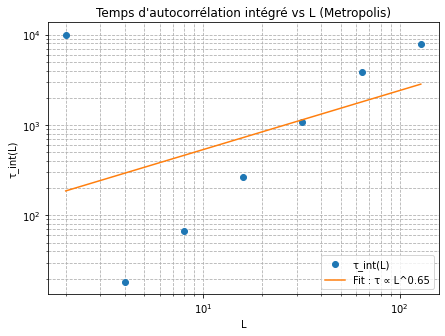

In [12]:
# Cellule 6 : Fit et visualisation
if len(tau_vs_L) < 2:
    print("Pas assez de points valides pour faire le fit.")
else:
    tau_vs_L = np.array(tau_vs_L)
    Ls = tau_vs_L[:,0]
    taus = tau_vs_L[:,1]

    logL = np.log(Ls)
    logtau = np.log(taus)

    slope, intercept, r_value, p_value, std_err = linregress(logL, logtau)
    z = slope 

    print("\n======================================")
    print(f"Exposant dynamique estimé : z = {z:.3f}")
    print(f"Coefficient R² = {r_value**2:.4f}")
    print("======================================\n")

    plt.close('all')
    plt.figure(figsize=(7,5))
    plt.loglog(Ls, taus, 'o', label="τ_int(L)")
    plt.loglog(Ls, np.exp(intercept) * Ls**z, label=f"Fit : τ ∝ L^{z:.2f}")
    plt.xlabel("L")
    plt.ylabel("τ_int(L)")
    plt.title("Temps d'autocorrélation intégré vs L (Metropolis)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()


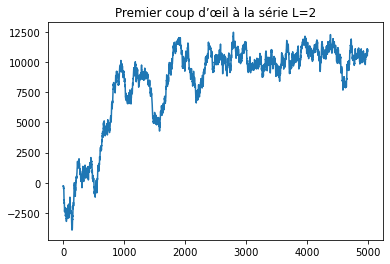

In [14]:
plt.plot(mags[:5000])
plt.title("Premier coup d’œil à la série L=2")
plt.show()
